In [63]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [64]:
load_dotenv()
load_dotenv(override=True)
model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7)

In [65]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback of the essay's strengths and weaknesses.")
    score: int = Field(description="A score from 1 to 10 evaluating the overall quality of the essay.", ge=0, le=10)

In [66]:
structured_model = model.with_structured_output(EvaluationSchema)

In [67]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [68]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [69]:
def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [70]:
def evaluate_thought(state: UPSCState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [71]:
def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [72]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

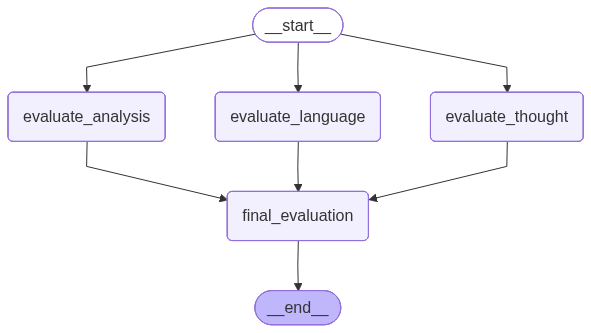

In [73]:
workflow

In [74]:
Essay = """ India, known as the land of festivals, is a country rich in culture, traditions, and diversity. Its festivals reflect the vibrant cultural fabric that unites people from different religions, regions, and languages. Every festival in India has its own unique significance, rooted in mythology, history, or seasonal changes, making them a harmonious blend of joy, devotion, and tradition.
Religious festivals hold a special place in Indian society. Diwali, the festival of lights, signifies the victory of good over evil, while Eid-ul-Fitr and Eid-ul-Adha celebrate faith and generosity. Christmas marks the birth of Jesus Christ and spreads the message of love and compassion. Festivals like Holi, known as the festival of colors, and Navratri, a nine-day celebration of divine feminine energy, bring communities together in lively festivities.
In addition to religious festivals, India also observes national events like Independence Day, Republic Day, and Gandhi Jayanti, which commemorate significant milestones in the country’s history. Regional festivals such as Onam in Kerala, Durga Puja in West Bengal, and Bihu in Assam showcase the diversity and cultural richness of various states.
These celebrations are not merely about rituals; they foster a sense of unity and togetherness. They bridge cultural gaps, strengthen family and community bonds, and provide a platform for preserving ancient traditions. Festivals also contribute significantly to the country’s economy by boosting tourism, local businesses, and artisanship.
In conclusion, the festivals of India are a true reflection of its cultural diversity and unity. They remind us of our shared heritage, instill values of love and harmony, and add vibrancy to everyday life. Celebrating these festivals allows us to embrace our roots while fostering a sense of national pride and global camaraderie.
Importance of Festivals in India Essay
Festivals in India hold immense cultural, social, and religious significance. They are not merely days of celebration but embody the essence of India’s unity in diversity. With numerous religions, regions, and traditions, Indian festivals showcase the country’s rich heritage and bring people together, transcending boundaries of caste, creed, and language.
Religious festivals like Diwali, Eid, Christmas, and Gurpurab convey profound spiritual meanings and promote values such as faith, generosity, and gratitude. Regional festivals like Pongal, Bihu, and Durga Puja celebrate the cultural identity of different states while highlighting the seasonal cycles of nature. National festivals, such as Independence Day and Republic Day, inspire patriotism and remind citizens of India’s historical struggles and achievements.
Festivals play a vital role in fostering social harmony and strengthening family bonds. They provide opportunities for people to reconnect, share joy, and express gratitude. Communities come alive with vibrant decorations, rituals, dances, music, and feasts, reflecting the spirit of togetherness.
Economically, festivals stimulate growth by boosting industries like tourism, retail, and handicrafts. Local markets thrive, and traditional artisans find a platform to showcase their craftsmanship. This contributes to sustaining India’s cultural heritage and supporting livelihoods.
In conclusion, festivals in India are more than celebrations; they are a way of life. They preserve traditions, promote unity, and infuse joy into everyday existence. By celebrating festivals, Indians not only honor their past but also strengthen their shared cultural identity and look forward to a harmonious future."""

In [75]:
intial_state = {
    'essay': Essay
}

workflow.invoke(intial_state)

{'essay': ' India, known as the land of festivals, is a country rich in culture, traditions, and diversity. Its festivals reflect the vibrant cultural fabric that unites people from different religions, regions, and languages. Every festival in India has its own unique significance, rooted in mythology, history, or seasonal changes, making them a harmonious blend of joy, devotion, and tradition.\nReligious festivals hold a special place in Indian society. Diwali, the festival of lights, signifies the victory of good over evil, while Eid-ul-Fitr and Eid-ul-Adha celebrate faith and generosity. Christmas marks the birth of Jesus Christ and spreads the message of love and compassion. Festivals like Holi, known as the festival of colors, and Navratri, a nine-day celebration of divine feminine energy, bring communities together in lively festivities.\nIn addition to religious festivals, India also observes national events like Independence Day, Republic Day, and Gandhi Jayanti, which commemo